Initializing Model. From subgraph_data.pkl load:
dict_keys(['fln_mat', 'sln_mat', 'hier_vals', 'areas'])
Running network with stimulation to V1


<Figure size 400x400 with 0 Axes>

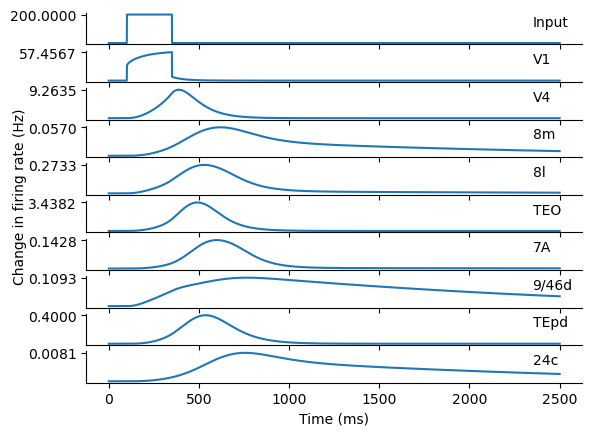

In [4]:
# -*- coding: utf-8 -*-
"""
A replication of
Chaudhuri, Rishidev, et al.
"A large-scale circuit mechanism for hierarchical dynamical processing in the primate cortex."
Neuron 88.2 (2015): 419-431.

Figure 7D can not be reproduced exactly because the parameters used to generate
the figure in original paper is of higher precision than the parameters reported.

"""
from __future__ import division

import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


def F(I, a=0.27, b=108., d=0.154):
    """F(I) for vector I"""
    return (a*I - b)/(1.-np.exp(-d*(a*I - b)))

class Model(object):
    """
    A model of multiple interacting brain areas from Chaudhuri et al. Neuron 2015

    """
    def __init__(self, datafile='subgraph_data.pkl', ext_params={}):
        #---------------------------------------------------------------------------------
        # Loading Anatomical Data from Kennedy's group
        #---------------------------------------------------------------------------------
        
        try:
            with open(datafile,'rb') as f:
                p = pickle.load(f)
        except UnicodeDecodeError:  # Python 3 compatibility with older pickles
            with open(datafile,'rb') as f:
                p = pickle.load(f, encoding='latin1')

        print('Initializing Model. From ' + datafile + ' load:')
        print(p.keys())

        p['hier_vals']   = p['hier_vals']/max(p['hier_vals']) # Normalized between 0 and 1
        p['n_area']      = len(p['areas'])

        #---------------------------------------------------------------------------------
        # Network Parameters
        #---------------------------------------------------------------------------------

        p['beta_inh']   = 0.351 # Hz/pA
        p['tau_exc']    = 60    # ms
        p['tau_inh']    = 10    # ms
        p['wEE']        = 250.2  # pA
        p['wIE']        = 303.9  # pA
        p['wEI']        = 8.11  # pA/Hz
        p['wII']        = 12.5  # pA/Hz
        p['muEE']       = 125.1  # pA/Hz
        p['eta']        = 3.4
        p['gamma']      = 0.641
        
        for key, value in ext_params.items():
            p[key] = value

        self.fI         = lambda x : x*(x>0) # f-I curve

        p['exc_scale']  = (1+p['eta']*p['hier_vals'])
        self.p          = p

    def run_stimulus(self, plotfile='ReplicateChaudhuri2015_Fig3A.pdf'):

        area_act        = 'V1'
        print('Running network with stimulation to ' + area_act)

        #---------------------------------------------------------------------------------
        # Redefine Parameters
        #---------------------------------------------------------------------------------

        p               = self.p

        # Definition of combined parameters

        local_EE        =  p['wEE'] * p['exc_scale']
        local_EI        = -p['wEI']
        local_IE        =  p['beta_inh'] * p['wIE'] * p['exc_scale']
        local_II        = -p['beta_inh'] * p['wII']

        fln_scaled      = (p['exc_scale'] * p['fln_mat'].T).T

        #---------------------------------------------------------------------------------
        # Simulation Parameters
        #---------------------------------------------------------------------------------

        dt              = 0.2   # ms
        T               = 2500  # ms
        t_plot          = np.linspace(0, T, int(T/dt)+1)
        n_t             = len(t_plot)

        I_bkg_exc = 400.0
        I_bkg_inh = 61.76

        # Solve for baseline gating variable and firing rates.
        def _solver(s_n):
            r_inh = p['beta_inh'] * (p['exc_scale'] * p['wIE'] *
                                     s_n + I_bkg_inh / p['beta_inh']) / (1 + p['beta_inh']
                                                                         * p['wII'])
            longrange_E = np.dot(fln_scaled,s_n)
            r_exc = F(local_EE * s_n + local_EI * r_inh + p['muEE'] * longrange_E +
                      I_bkg_exc)
            return s_n - p['gamma'] * (p['tau_exc'] /
                                       1000) * r_exc / (1 + p['gamma'] * (p['tau_exc'] /
                                                                          1000) * r_exc)
        x0 = np.ones(p['n_area']) * 0.05
        s_n_tgt = least_squares(_solver, x0, bounds=(np.zeros(p['n_area']),
                                                     np.ones(p['n_area'])))['x']
        r_inh_tgt = p['beta_inh'] * (p['exc_scale'] * p['wIE'] *
                                     s_n_tgt + I_bkg_inh /
                                     p['beta_inh']) / (1 + p['beta_inh'] * p['wII'])
        longrange_E = np.dot(fln_scaled,s_n_tgt)
        I_exc       = local_EE*s_n_tgt + local_EI*r_inh_tgt + \
                       p['muEE'] * longrange_E + I_bkg_exc
        r_exc_tgt = F(I_exc)

        # Set stimulus input
        I_stim_exc      = np.zeros((n_t,p['n_area']))

        area_stim_idx   = p['areas'].index(area_act) # Index of stimulated area
        time_idx        = (t_plot>100) & (t_plot<=350)
        I_stim_exc[time_idx, area_stim_idx] = 200.0

        #---------------------------------------------------------------------------------
        # Storage
        #---------------------------------------------------------------------------------

        s_n             = np.zeros((n_t,p['n_area']))
        r_exc           = np.zeros((n_t,p['n_area']))
        r_inh           = np.zeros((n_t,p['n_area']))

        #---------------------------------------------------------------------------------
        # Initialization
        #---------------------------------------------------------------------------------

        # Set activity to background firing
        s_n[0]          = s_n_tgt
        r_inh[0]        = r_inh_tgt
        r_exc[0]        = r_exc_tgt

        #---------------------------------------------------------------------------------
        # Running the network
        #---------------------------------------------------------------------------------

        for i_t in range(1, n_t):

            d_s_n = -s_n[i_t-1] + p['gamma'] * (p['tau_exc']/
                                                1000) * (1-s_n[i_t-1]) * r_exc[i_t-1]
            s_n[i_t]    = s_n[i_t-1] + d_s_n * dt/p['tau_exc']

            longrange_E = np.dot(fln_scaled,s_n[i_t])

            I_exc       = local_EE*s_n[i_t] + local_EI*r_inh[i_t-1] + \
                           p['muEE'] * longrange_E + I_bkg_exc + I_stim_exc[i_t]

            I_inh       = local_IE*s_n[i_t] + local_II*r_inh[i_t-1] + I_bkg_inh

            d_r_inh     = -r_inh[i_t-1] + self.fI(I_inh)

            r_exc[i_t]  = F(I_exc)
            r_inh[i_t]  = r_inh[i_t-1] + d_r_inh * dt/p['tau_inh']

        #---------------------------------------------------------------------------------
        # Plotting the results
        #---------------------------------------------------------------------------------

        _ = plt.figure(figsize=(4,4))
        area_name_list  = ['V1','V4','8m','8l','TEO','7A','9/46d','TEpd','24c']
        area_idx_list   = [-1]+[p['areas'].index(name) for name in area_name_list]
        f, ax_list      = plt.subplots(len(area_idx_list), sharex=True)

        for ax, area_idx in zip(ax_list, area_idx_list):
            if area_idx < 0:
                y_plot  = I_stim_exc[:, area_stim_idx]
                txt     = 'Input'
            else:
                y_plot  = r_exc[:,area_idx]
                txt     = p['areas'][area_idx]

            y_plot = y_plot - y_plot.min()
            ax.plot(t_plot, y_plot)
            ax.text(0.9, 0.6, txt, transform=ax.transAxes)

            ax.set_yticks([y_plot.max()])
            ax.set_yticklabels(['{:0.4f}'.format(y_plot.max())])
            ax.spines["right"].set_visible(False)
            ax.spines["top"].set_visible(False)
            ax.xaxis.set_ticks_position('bottom')
            ax.yaxis.set_ticks_position('left')

        f.text(0.01, 0.5, 'Change in firing rate (Hz)', va='center', rotation='vertical')
        ax.set_xlabel('Time (ms)')

        if plotfile is not None:
            #plt.savefig(plotfile)
            print('Figure saved at ' + str(plotfile))
        

if __name__ == '__main__':
    model = Model()
    model.run_stimulus(plotfile=None) # Run stimulation to V1
